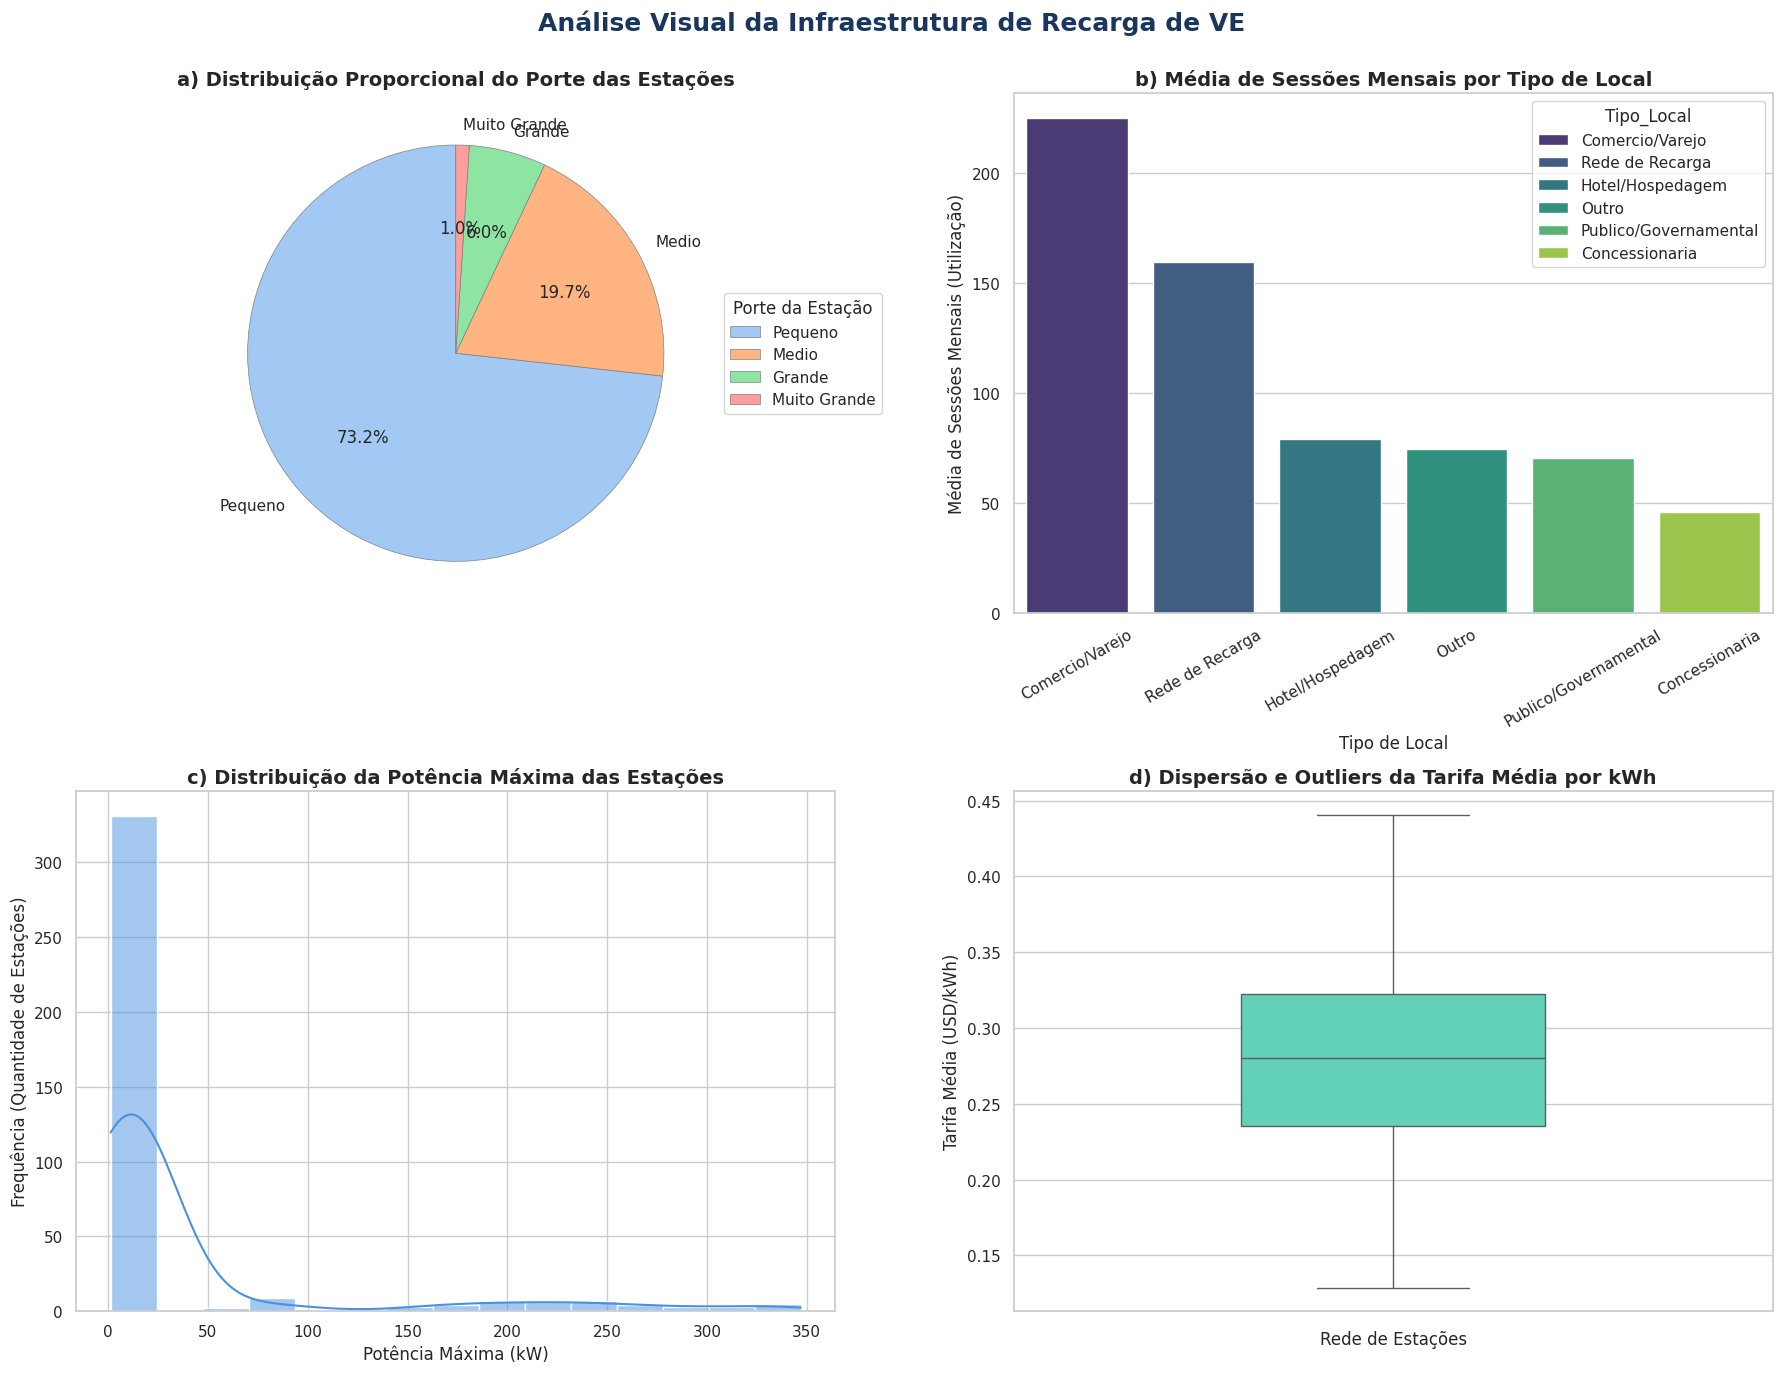


-----------------------------------------------------------------
ANÁLISE ESTATÍSTICA UNIVARIADA: SESSÕES MENSAIS (USO)
-----------------------------------------------------------------
a) Medidas de Tendência Central:
   - Média:   88.0104
   - Mediana: 54.0000
   - Moda:    46.0000

b) Medidas de Dispersão:
   - Variância:     11506.6093
   - Desvio Padrão: 107.2689
   - Amplitude:     779.0000

c) Medidas Separatrizes (Quartiz):
   - Primeiro Quartil (Q1 - 25%): 37.0000
   - Segundo Quartil (Q2 - 50%):  54.0000 (Mediana)
   - Terceiro Quartil (Q3 - 75%): 92.0000

-----------------------------------------------------------------
ANÁLISE ESTATÍSTICA UNIVARIADA: TARIFA MÉDIA POR KWH (PREÇO)
-----------------------------------------------------------------
a) Medidas de Tendência Central:
   - Média:   0.2822
   - Mediana: 0.2800
   - Moda:    0.3345

b) Medidas de Dispersão:
   - Variância:     0.0030
   - Desvio Padrão: 0.0547
   - Amplitude:     0.3120

c) Medidas Separatrizes (Quar

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÃO DE ESTILO E CARREGAMENTO DOS DADOS
sns.set_theme(style="whitegrid")

# Carrega a base de dados real enviada
df = pd.read_csv('base_estacoes_recarga_ev.csv')

# ==============================================================================
# ATIVIDADE 01: ANÁLISES GRÁFICAS (Consolidadas em uma única figura)
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Análise Visual da Infraestrutura de Recarga de VE', fontsize=18, fontweight='bold', color='#1a365d')

# --- a) Gráfico de Setores (Pie Chart) ---
# Variável: Porte_Estacao (Percentual de estações por tamanho)
contagem_porte = df['Porte_Estacao'].value_counts()
cores_pie = sns.color_palette('pastel')[0:len(contagem_porte)]
axs[0, 0].pie(contagem_porte, labels=contagem_porte.index, autopct='%1.1f%%',
              colors=cores_pie, startangle=90, wedgeprops={'edgecolor': 'gray', 'linewidth': 0.5})
axs[0, 0].set_title('a) Distribuição Proporcional do Porte das Estações', fontsize=14, fontweight='bold')
axs[0, 0].legend(contagem_porte.index, title="Porte da Estação", loc="center left", bbox_to_anchor=(1, 0.5))

# --- b) Gráfico de Barras (Bar Chart) ---
# Variável: Média de Sessões Mensais por Tipo de Local
media_sessoes_local = df.groupby('Tipo_Local')['Sessoes_Mensais'].mean().reset_index().sort_values(by='Sessoes_Mensais', ascending=False)
sns.barplot(data=media_sessoes_local, x='Tipo_Local', y='Sessoes_Mensais',
            hue='Tipo_Local', palette='viridis', ax=axs[0, 1], legend=True)
axs[0, 1].set_title('b) Média de Sessões Mensais por Tipo de Local', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Tipo de Local', fontsize=12)
axs[0, 1].set_ylabel('Média de Sessões Mensais (Utilização)', fontsize=12)
axs[0, 1].tick_params(axis='x', rotation=30)

# --- c) Histograma ---
# Variável: Potencia_Maxima_kW (Distribuição da capacidade técnica de carregamento)
sns.histplot(df['Potencia_Maxima_kW'], bins=15, color='#4a90e2', kde=True, ax=axs[1, 0])
axs[1, 0].set_title('c) Distribuição da Potência Máxima das Estações', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Potência Máxima (kW)', fontsize=12)
axs[1, 0].set_ylabel('Frequência (Quantidade de Estações)', fontsize=12)

# --- d) Boxplot ---
# Variável: Tarifa_Media_kWh (Análise de preços e dispersão do custo de recarga)
sns.boxplot(y=df['Tarifa_Media_kWh'], color='#50e3c2', ax=axs[1, 1], width=0.4,
            flierprops={'markerfacecolor': 'red', 'marker': 'o', 'markersize': 6})
axs[1, 1].set_title('d) Dispersão e Outliers da Tarifa Média por kWh', fontsize=14, fontweight='bold')
axs[1, 1].set_ylabel('Tarifa Média (USD/kWh)', fontsize=12)
axs[1, 1].set_xlabel('Rede de Estações', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# ==============================================================================
# ATIVIDADE 02: ANÁLISE UNIVARIADA (ESTATÍSTICA DESCRITIVA)
# ==============================================================================
def calcular_estatisticas_univariadas(coluna_nome, serie):
    print(f"\n{'-'*65}")
    print(f"ANÁLISE ESTATÍSTICA UNIVARIADA: {coluna_nome.upper()}")
    print(f"{'-'*65}")

    # a) Medidas de Tendência Central
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()[0] if not serie.mode().empty else np.nan
    print("a) Medidas de Tendência Central:")
    print(f"   - Média:   {media:.4f}")
    print(f"   - Mediana: {mediana:.4f}")
    print(f"   - Moda:    {moda:.4f}")

    # b) Medidas de Dispersão
    variancia = serie.var()
    desvio_padrao = serie.std()
    amplitude = serie.max() - serie.min()
    print("\nb) Medidas de Dispersão:")
    print(f"   - Variância:     {variancia:.4f}")
    print(f"   - Desvio Padrão: {desvio_padrao:.4f}")
    print(f"   - Amplitude:     {amplitude:.4f}")

    # c) Medidas Separatrizes
    q1 = serie.quantile(0.25)
    q2 = serie.quantile(0.50)
    q3 = serie.quantile(0.75)
    print("\nc) Medidas Separatrizes (Quartiz):")
    print(f"   - Primeiro Quartil (Q1 - 25%): {q1:.4f}")
    print(f"   - Segundo Quartil (Q2 - 50%):  {q2:.4f} (Mediana)")
    print(f"   - Terceiro Quartil (Q3 - 75%): {q3:.4f}")

# Execução obrigatória para 2 variáveis contínuas cruciais do negócio
calcular_estatisticas_univariadas("Sessões Mensais (Uso)", df['Sessoes_Mensais'])
calcular_estatisticas_univariadas("Tarifa Média por kWh (Preço)", df['Tarifa_Media_kWh'])